In [1089]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [1090]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1091]:
df=pd.read_csv('/content/drive/MyDrive/customer_segmentation (1).csv')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [1092]:
df.shape

(2240, 29)

In [1093]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [1094]:
df.isna().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [1095]:
df['AcceptedCmp2'].value_counts()

,count
AcceptedCmp2,
0,2210
1,30


In [1096]:
df['Z_CostContact'].unique()

array([3])

In [1097]:
df.duplicated().sum()

np.int64(0)

In [1098]:
df=df.iloc[:,8:10].values

In [1099]:
df

array([[ 58, 635],
       [ 38,  11],
       [ 26, 426],
       ...,
       [ 91, 908],
       [  8, 428],
       [ 40,  84]])

In [1100]:
from sklearn.preprocessing import StandardScaler

In [1101]:
# scalar=StandardScaler()
# df=scalar.fit_transform(df)

In [1102]:
df

array([[ 58, 635],
       [ 38,  11],
       [ 26, 426],
       ...,
       [ 91, 908],
       [  8, 428],
       [ 40,  84]])

# Hierarchical Clustering

In [1103]:
import scipy.cluster.hierarchy as shc

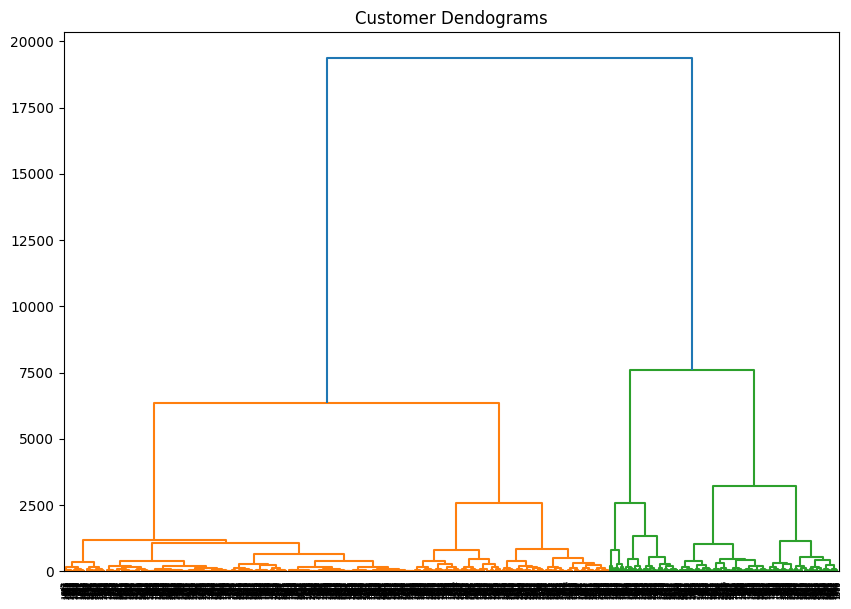

In [1104]:
plt.figure(figsize=(10, 7))
plt.title("Customer Dendograms")
dend=shc.dendrogram(shc.linkage(df, method='ward'))

In [1105]:
from sklearn.cluster import AgglomerativeClustering

In [1106]:
cluster=AgglomerativeClustering(n_clusters=4)
labels=cluster.fit_predict(df)

In [1107]:
labels

array([0, 3, 1, ..., 2, 1, 3])

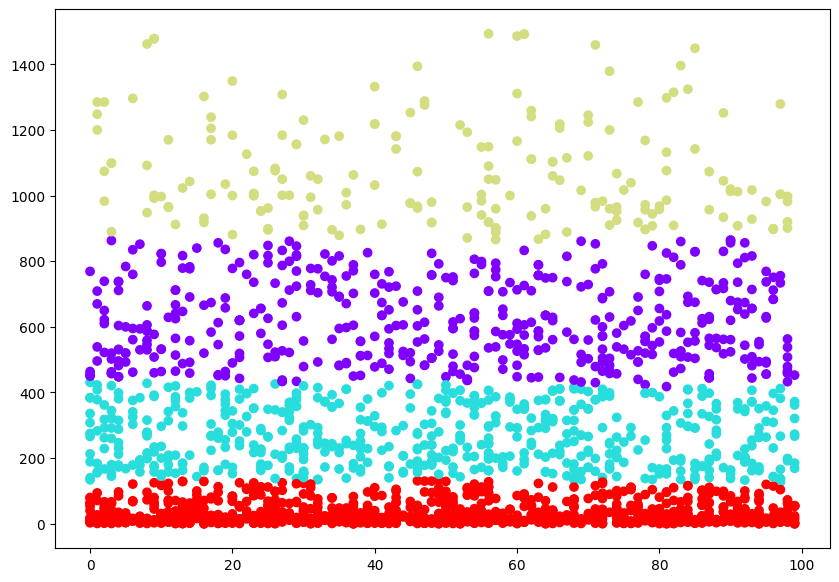

In [1108]:
plt.figure(figsize=(10,7))
plt.scatter(df[:,0],df[:,1],c=labels,cmap='rainbow')
plt.show()

# K-Mean Clustering

In [1109]:
from sklearn.preprocessing import StandardScaler

In [1110]:
scalar=StandardScaler()
df=scalar.fit_transform(df)

In [1111]:
df

array([[ 0.30703926,  0.98378127],
       [-0.38366418, -0.87047948],
       [-0.79808624,  0.36272278],
       ...,
       [ 1.44669994,  1.79502034],
       [-1.41971934,  0.36866592],
       [-0.31459383, -0.65355475]])

In [1112]:
from sklearn.cluster import KMeans

# Albow method

In [1113]:
wsscs=[]
k_range=range(1,11)

In [1114]:
for K in k_range:
  kmeans=KMeans(n_clusters=K,random_state=42)
  kmeans.fit(df)
  wsscs.append(kmeans.inertia_)

In [1115]:
wsscs

[4480.000000000002,
 2818.4487788188867,
 1506.5897214192378,
 1147.2063451476292,
 952.555903227823,
 734.033130360256,
 609.4030815207431,
 520.7475164432218,
 463.1423294665619,
 416.8876511825046]

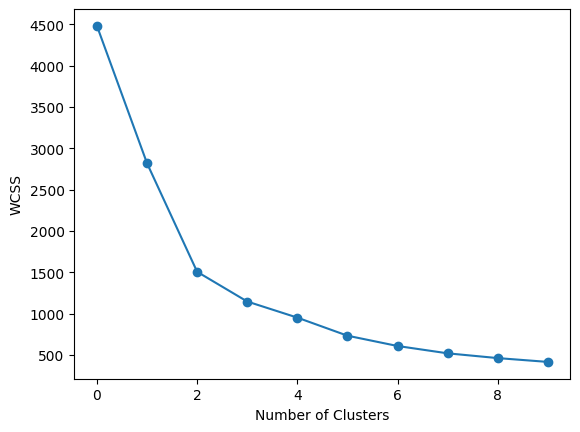

In [1116]:
plt.plot(wsscs,marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()


In [1117]:
k_mean_final=KMeans(n_clusters=4,random_state=42)
k_means_labels=k_mean_final.fit_predict(df)


In [1118]:
k_means_labels

array([2, 0, 0, ..., 2, 0, 0], dtype=int32)

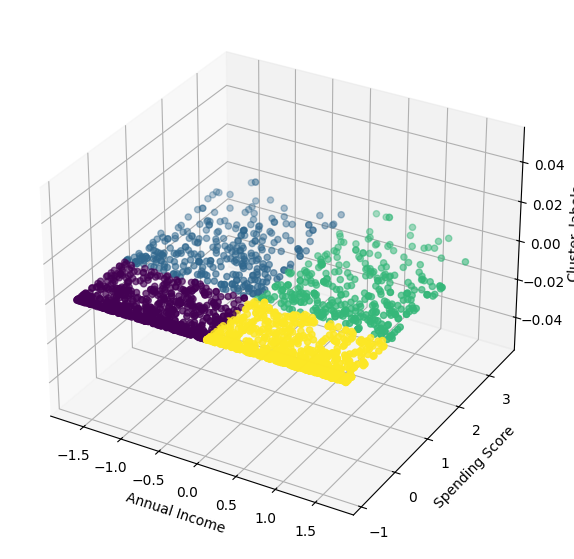

In [1119]:
fig=plt.figure(figsize=(10,7))
ax=fig.add_subplot(111,projection='3d')
ax.scatter(df[:,0],df[:,1],c=k_means_labels)
ax.set_xlabel('Annual Income')
ax.set_ylabel('Spending Score')
ax.set_zlabel('Cluster_labels')
plt.show()

# DBSCAN

In [1120]:
# Import DBSCAN clustering algorithm from sklearn
from sklearn.cluster import DBSCAN

In [1121]:
# Create a DBSCAN model
# eps = maximum distance between two points to be considered neighbors
# min_samples = minimum number of points required to form a dense region (cluster)
dbscan=DBSCAN(eps=0.3,min_samples=3)



# Fit the DBSCAN model on dataset 'df' and assign cluster labels
# fit_predict() trains the model and returns cluster numbers for each data point
label = dbscan.fit_predict(df)


# 'label' will contain:
# 0,1,2,... = cluster IDs
# -1 = noise points (outliers that do not belong to any cluster)

In [1122]:
label

array([0, 0, 0, ..., 0, 0, 0])

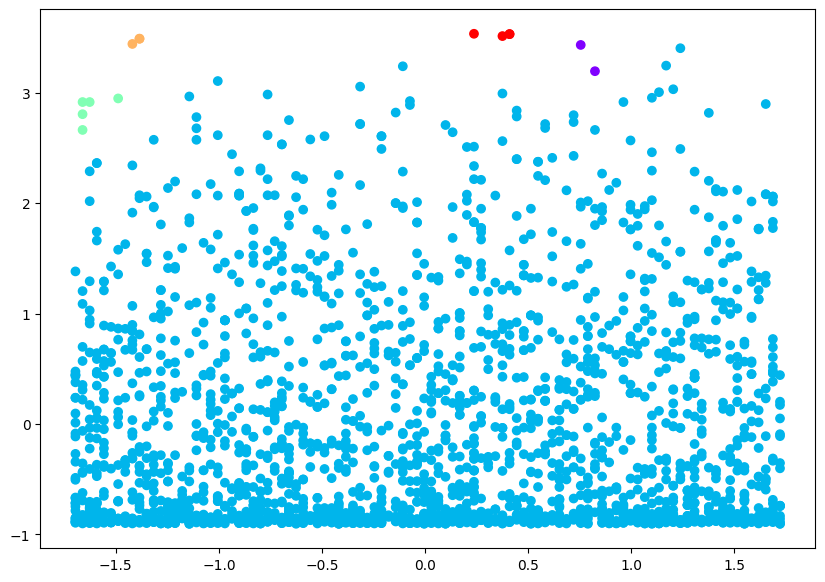

In [1123]:
plt.figure(figsize=(10,7))
plt.scatter(df[:,0],df[:,1],c=label,cmap='rainbow')
plt.show()

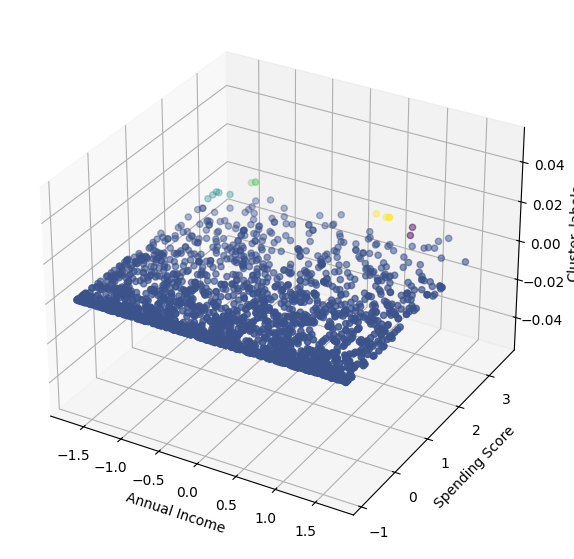

In [1124]:
fig=plt.figure(figsize=(10,7))
ax=fig.add_subplot(111,projection='3d')
ax.scatter(df[:,0],df[:,1],c=label)

ax.set_xlabel('Annual Income')
ax.set_ylabel('Spending Score')
ax.set_zlabel('Cluster_labels')
plt.show()